loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-1 in yolov8:: 100%|██████████| 1338/1338 [00:00<00:00, 2207.82it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-players-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.

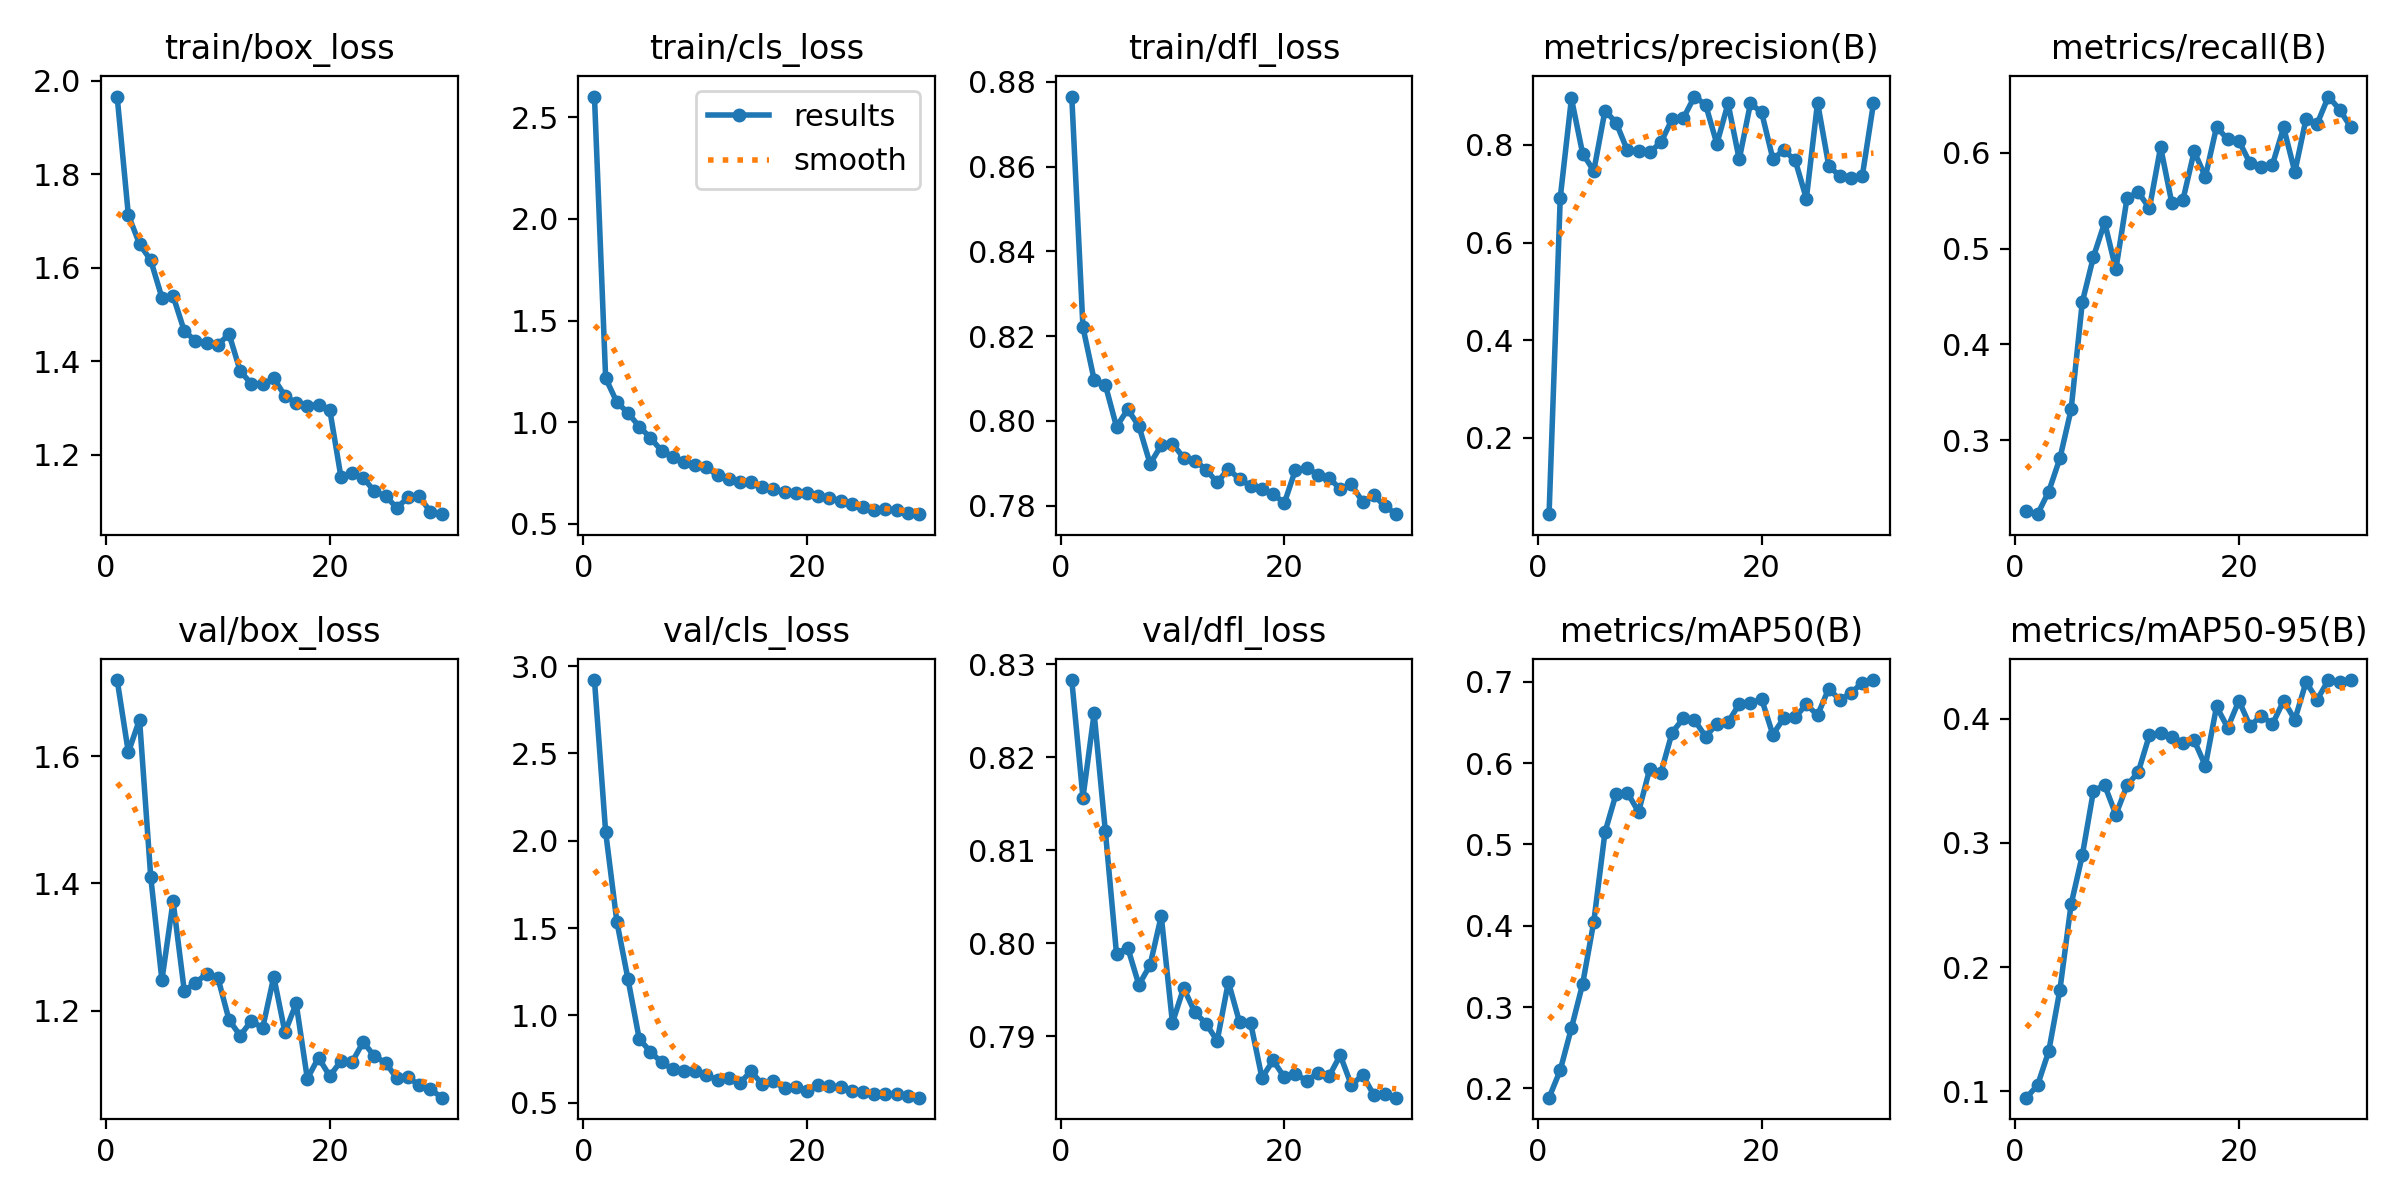


image 1/13 /content/football-players-detection-1/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg: 384x640 23 players, 68.5ms
image 2/13 /content/football-players-detection-1/test/images/42ba34_1_5_png.rf.4337fde8fbe3640cf4351fb41ac9c3ca.jpg: 384x640 1 goalkeeper, 24 players, 1 referee, 15.9ms
image 3/13 /content/football-players-detection-1/test/images/42ba34_5_5_png.rf.ceb556bd4c92d41496ae1d8c56600c4a.jpg: 384x640 1 goalkeeper, 21 players, 2 referees, 10.8ms
image 4/13 /content/football-players-detection-1/test/images/4b770a_1_4_png.rf.5a45b3b841a06de414ceb802e34c136f.jpg: 384x640 1 goalkeeper, 20 players, 3 referees, 12.7ms
image 5/13 /content/football-players-detection-1/test/images/4b770a_3_6_png.rf.d0d9403f2f73ca0da7a6a1373c02b749.jpg: 384x640 1 goalkeeper, 21 players, 3 referees, 10.3ms
image 6/13 /content/football-players-detection-1/test/images/573e61_1_9_png.rf.e82af77d907cdc12dccbd6857f53b9b1.jpg: 384x640 20 players, 2 referees, 6.5ms
image 7/13 /content/f

In [ ]:
# 셀 1: 설치
!pip install ultralytics roboflow
# ultralytics는 YOLOv8을 만든 회사 라이브러리
# roboflow 데이터셋 관리 플랫폼의 라이브러리

# 셀2: 데이터셋 다운로드
from roboflow import Roboflow
rf = Roboflow(api_key='API키 작성')
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
# detection 탐지
version = project.version(1)
# version 1: 원본 이미지 372장 그대로
# version 2: 이미지 증강(augmentation) 적용 -> 이미지 늘림
# version 3: 전처리 바꿈 (크기 변경, 그레이스케일 등)
# augmentation: 가지고 있는 적은 양의 데이터를 뻥튀기해서 AI를 훈련시키는 기법
# 그레이스케일: 밝기(명암)정보만을 사용하여 흑백으로 표현하는 방식
dataset = version.download("yolov8")
# 데이터를 YOLOv8이 읽을 수 있는 형식(폴더 구조 + 라벨 형식)

# 셀3: 학습 (GPU)
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
# yolov8n -> nano (가장 작고 빠름, 정확도 낮음)
# yolov8s -> small
# yolov8m -> medium
# yolov8l -> large
# yolov8x -> extra large (가장 크고 느림, 정확도 높음)
results = model.train(
    data=dataset.location + '/data.yaml',
    # Roboflow에서 다운받은 폴더 경로
    # data.yaml 안에 내용
    # train: /content/football-players-detection-1/train/images
    # val: /content/football-players-detection-1/valid/images
    # nc: 4
    # names: ['ball', 'player', 'referee', 'goalkeeper'] # 클래스 이름
    epochs=30,
    # 전체 데이터셋을 30번 반복해서 학습
    imgsz=640,
    # 이미지 크기(픽셀)
    # 원본 이미지를 리사이즈해서 학습에 넣음
    batch=16,
    # 이미지를 한 장씩 학습하면 너무 느리고 불안정함
    # 그래서 여러 장을 묶어서 한꺼번에 학습
    # 예) 전체 372장이면:
    # 372 / 16 = 약 23번 업데이트 ( = 1 에폭)
    device=0
    # device=0 -> 첫 번째 GPU 사용
    # device=1 -> 두 번째 GPU
    # device='cpu' -> CPU 사용
)

# 셀 4: 결과 확인
from IPython.display import Image, display
display(Image(filename='runs/detect/train/results.png'))
# 학습이 끝나면 YOLO가 자동으로 결과 그래프를 저장
# loss, mAP, precision, recall 그래프가 이 파일

# 셀 5: 테스트 추론
model = YOLO('runs/detect/train/weights/best.pt')
# 30 에폭 중에서 mAP가 가장 높았던 모델을 불러옴
results = model(dataset.location + '/test/images', save=True)
# 학습에 쓰지 않은 테스트 이미지로 진짜 실력 확인
# save=True -> 검출 결과를 runs/detect/predict/에 저장

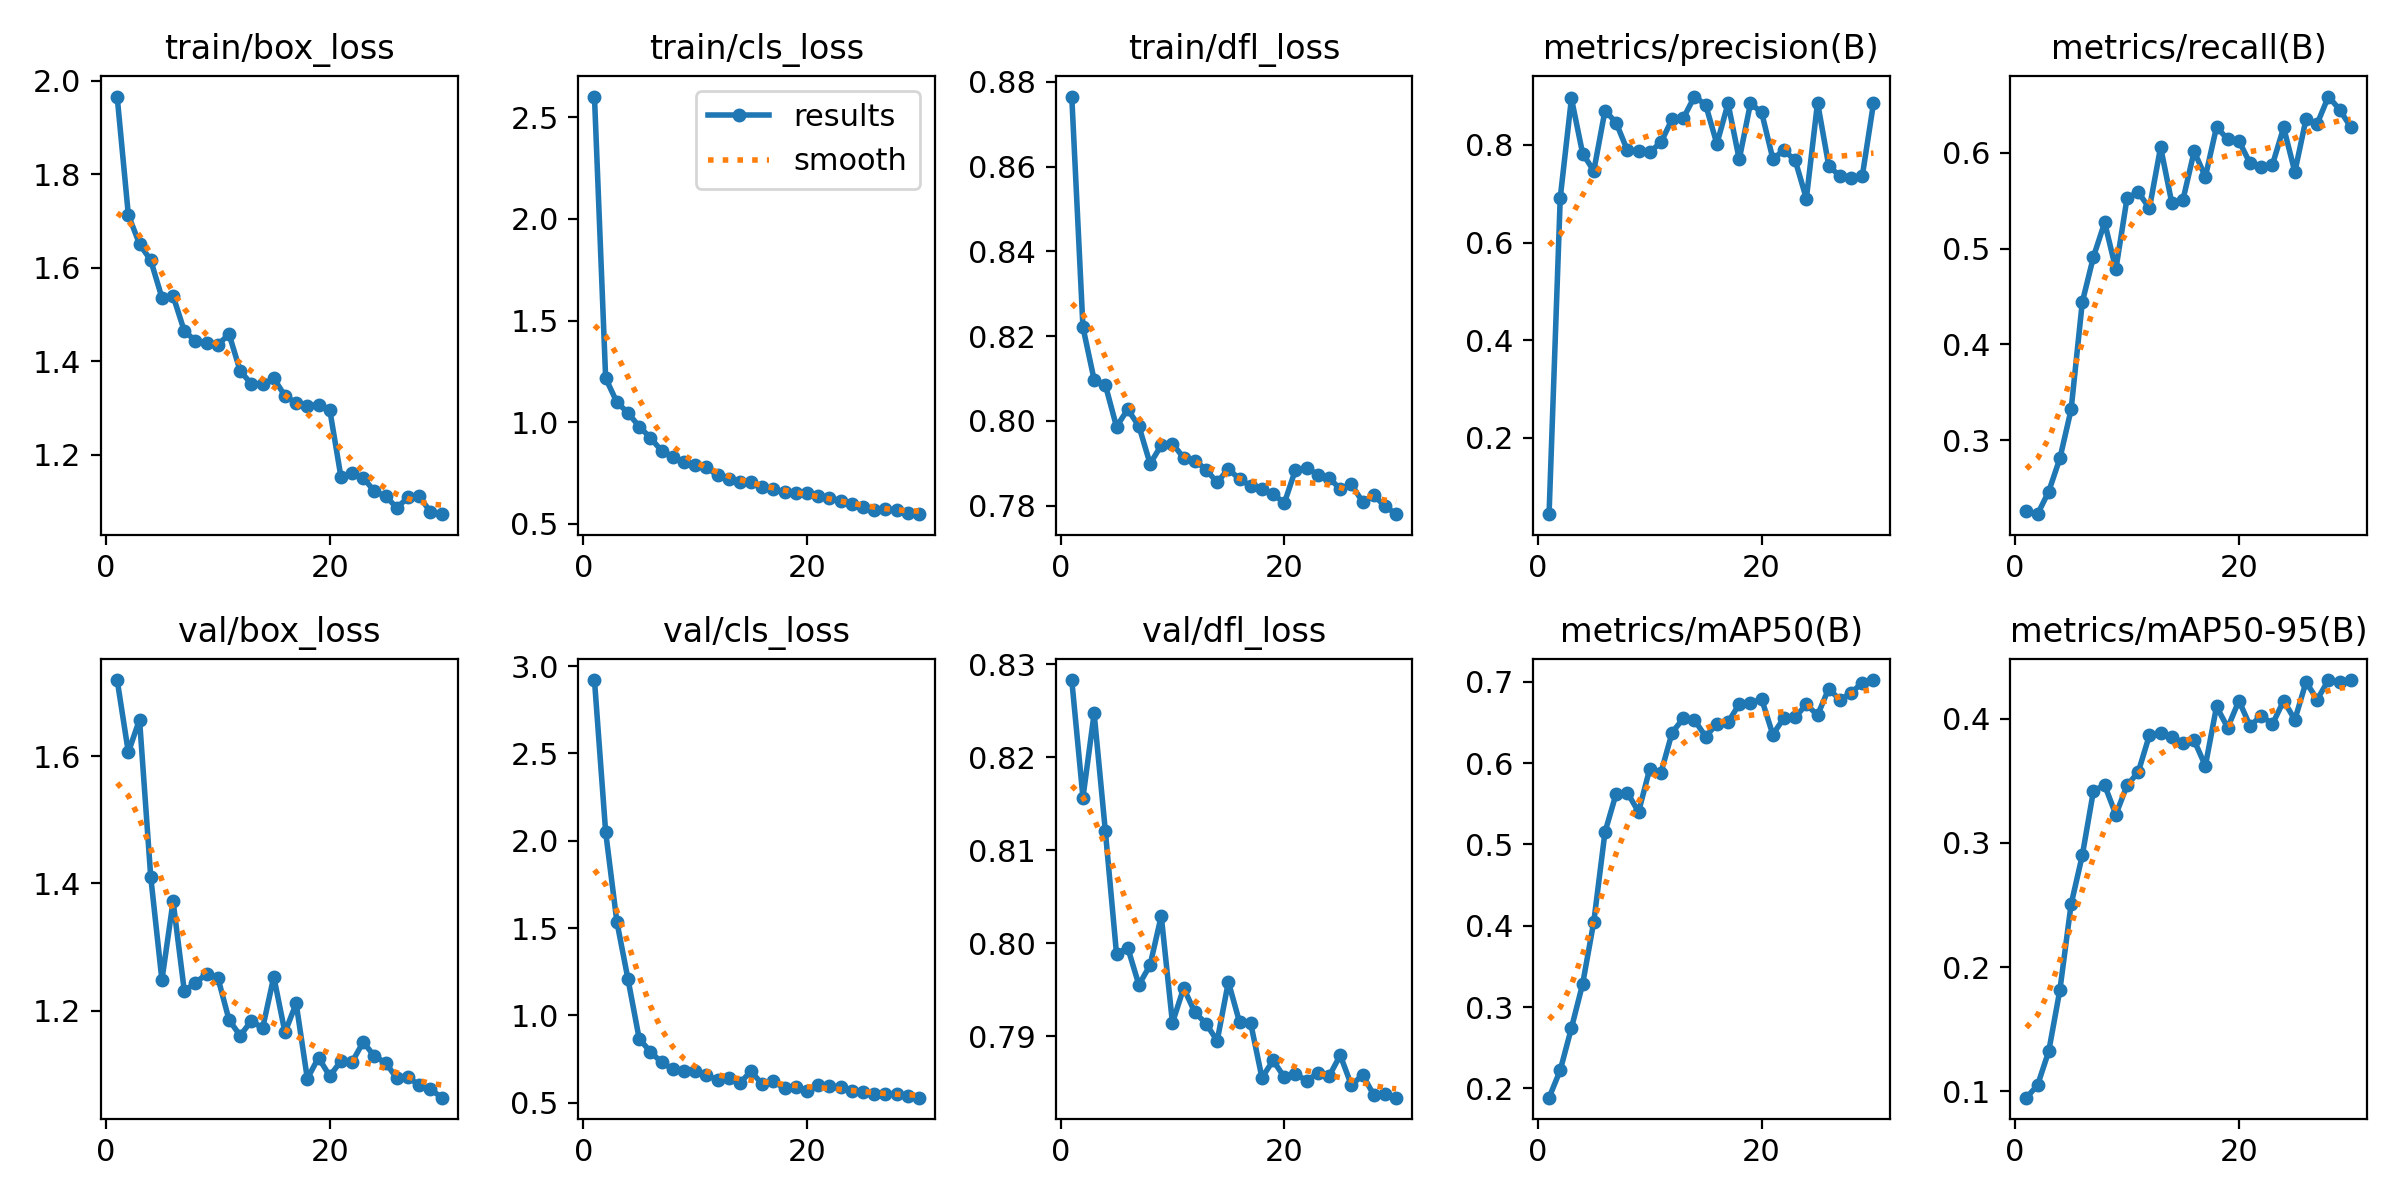

In [ ]:
from IPython.display import Image, display
# IPython.display: Colab 노트북에서 이미지를 화면에 보여주는 모듈
# Image: 이미지 파일을 불러오는 클래스
# display: 불러온 이미지를 화면에 표시하는 함수

display(Image(filename='runs/detect/train/results.png'))
# runs/detect/train/results.png -> 학습 끝나면 YOLO가 자동 저장하는 그래프
# loss(box, cls, dfl), precision, recall, mAP 변화를 하눈에 볼 수 있음

In [ ]:
import glob
# glob: 파일 경로를 패턴으로 검색하는 모듈

from IPython.display import Image,display
# Image, display: Colab 노트북에서 이미지를 화면에 보여주는 도구

for img in glob.glob('runs/detect/predict/*.jpg')[:5]:
    # 'runs/detect/predict/*.jpg' -> predict 폴더 안의 모든 jpg 파일 검색
    # *.jpg -> *는 "아무 이름이나 다" 라는 뜻 (와일드카드)
    # [:5] -> 그 중 앞에서 5장만 가져옴 (너무 많으면 화면 넘치니까)
    display(Image(filename=img, width=600))
    # 이미지를 가로 600px 크기로 화면에 표시

Output hidden; open in https://colab.research.google.com to view.